# ** Business Understanding **
Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. These ingredients include cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, and fine aggregate.

[Data Source Link](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength)

Sources: 

  Original Owner and Donor
  Prof. I-Cheng Yeh
  Department of Information Management 
  Chung-Hua University, 
  Hsin Chu, Taiwan 30067, R.O.C.
  e-mail:icyeh@chu.edu.tw
  TEL:886-3-5186511

  Date Donated: August 3, 2007

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy import stats

## ** Load Data**

In [59]:
strength_df = pd.read_excel('data/Concrete_Data.xlsx')

## ** Data Understanding: **
- glimpse of the data(head, tail)
- shape(dimensions)
- columns
- information
- data type
- duplicates
- outliers
- null values
- descriptive stats (quantitative and qualitative)

## ** Glimpse of the Data **

In [61]:
strength_df.head(5)

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [62]:
strength_df.tail()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.401235


## ** Dimensions, Columns & Datatypes **

In [63]:
rows, columns = df.shape
output = f"Records: {rows} and Features: {columns}"
print(output)

Records: 1030 and Features: 9


In [64]:
strength_df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')

In [65]:
strength_df.dtypes

Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                  int64
Concrete compressive strength(MPa, megapascals)          float64
dtype: object

## ** Info, Duplicates, Null Values **

In [66]:
strength_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)        1030 

In [67]:
strength_df.duplicated().sum()

np.int64(25)

In [68]:
strength_df.isna().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [69]:
strength_df.isnull().sum() * 100 / len(df)

Cement (component 1)(kg in a m^3 mixture)                0.0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0.0
Fly Ash (component 3)(kg in a m^3 mixture)               0.0
Water  (component 4)(kg in a m^3 mixture)                0.0
Superplasticizer (component 5)(kg in a m^3 mixture)      0.0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0.0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0.0
Age (day)                                                0.0
Concrete compressive strength(MPa, megapascals)          0.0
dtype: float64

In [70]:
strength_df.isnull().sum() * 100 / len(df)

Cement (component 1)(kg in a m^3 mixture)                0.0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0.0
Fly Ash (component 3)(kg in a m^3 mixture)               0.0
Water  (component 4)(kg in a m^3 mixture)                0.0
Superplasticizer (component 5)(kg in a m^3 mixture)      0.0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0.0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0.0
Age (day)                                                0.0
Concrete compressive strength(MPa, megapascals)          0.0
dtype: float64

In [71]:
strength_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)        1030 

#### ** Descriptive Stats (Quantitative and Qualitative) **

In [72]:
strength_df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [73]:
strength_df.describe(include='object') # qualitative data

ValueError: No columns match the specified include or exclude data types

In [74]:
strength_df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [90]:
strength_df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')

In [76]:

# (Optional) Shorten the long target name for convenience
dstrength_df = df.rename(columns={
    'Concrete compressive strength(MPa, megapascals)': 'strength'
})

In [77]:
strength_df.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')

## ** Visualizations **

In [58]:
# pie chart
def plotPieChart(labels, data):
    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels)

In [81]:
strength_labels  = strength_df['Concrete compressive strength(MPa, megapascals) '].unique()
strength_labels

array([79.98611076, 61.88736576, 40.26953526, 41.05277999, 44.2960751 ,
       47.02984744, 43.6982994 , 36.44776979, 45.85429086, 39.28978986,
       38.07424367, 28.02168359, 43.01296026, 42.32693164, 47.81378165,
       52.90831981, 39.35804798, 56.14196225, 40.56325203, 42.62064842,
       41.8367142 , 28.23748958,  8.06342182, 44.20782217, 52.51669744,
       53.30063166, 41.15137506, 52.1243856 , 37.42751518, 38.60376124,
       55.26012245, 41.71950328, 42.13112046, 53.69225402, 38.40795006,
       30.07976945, 37.72192144, 42.22902605, 36.2519586 , 50.45930106,
       38.99538361, 53.104131  , 41.54299743, 35.07640202, 15.04919265,
       40.75906322, 26.25800398, 32.82319446, 39.77931782, 46.93194184,
       33.11691123, 49.18514941, 14.58931216, 14.63826496, 41.9346198 ,
        9.13142014, 50.94882902, 33.01900564, 54.37828264, 51.73276323,
        9.86640156, 50.65511224, 48.69562145, 55.06431126, 44.6980396 ,
       30.27558064, 40.85696881, 71.98818916, 34.39795764, 28.79

In [82]:
strength_df['Concrete compressive strength(MPa, megapascals) '].value_counts()

Concrete compressive strength(MPa, megapascals) 
33.398217    5
35.301171    4
71.298713    4
77.297154    4
79.296635    4
            ..
44.284354    1
31.178794    1
23.696601    1
32.768036    1
32.401235    1
Name: count, Length: 938, dtype: int64

In [ ]:
data = list(strength_df['Concrete compressive strength(MPa, megapascals) '].value_counts())
data

[5,
 4,
 4,
 4,
 4,
 4,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


## ** Insights **
- The dataset in quantitative in nature
- The dataset is made up of 1030 Records and 9 Features
- The dataset has 2 data types


** Cement Strength Process : **
- there were 1030.000000 iterations of measuring cement components to derive the optimum mixture affecting strength 
- The test has a min result of  of 2.33 MPa
- The test has a max result of 82.60 MPa
- 25% of the tests returned less than 23.707115 MPa
- 50% (median) of the tests returned around 34.442774 MPa
- 75% of the of the tests returned less than 46.136287 MPa

In [92]:
strength_df.describe(include='object') # qualitative data

ValueError: No columns match the specified include or exclude data types

In [93]:
strength_df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


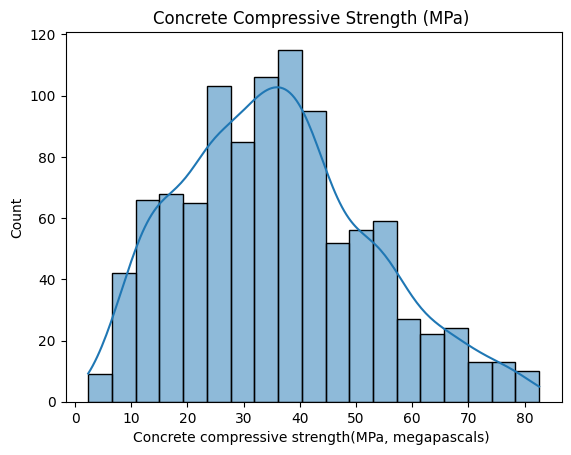

In [97]:
sns.histplot(strength_df['Concrete compressive strength(MPa, megapascals) '], kde=True)

plt.title("Concrete Compressive Strength (MPa) ")
plt.show()

In [98]:
# MoVs
sd = np.std(strength_df) 
variance = np.var(strength_df)
range_of_values = np.max(strength_df) - np.min(strength_df) 
output = f"VARIANCE: {variance} || STANDARD DEVIATION: {sd} || RANGE: {range_of_values}"
print(output) 

VARIANCE: 117230.69118684421 || STANDARD DEVIATION: 342.38967739528044 || RANGE: 1145.0


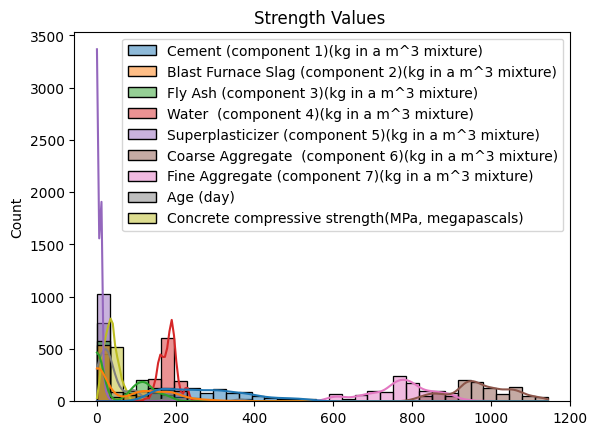

In [100]:
sns.histplot(strength_df, kde=True)
plt.title("Strength Values ")
plt.show()

## ** Poisson Distribution **

In [101]:
strength_df.dtypes

Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                  int64
Concrete compressive strength(MPa, megapascals)          float64
dtype: object

In [ ]:
strength_df['Concrete compressive strength(MPa, megapascals) '].max() -  strength_df['Concrete compressive strength(MPa, megapascals) '].min() # getting the difference betwen min and max

np.float64(80.267416968)

Insight:
- it highlights 80.267416968 as the difference between min and max MPa

#### **Calculate the parameter λ**

In [ ]:
lambda_hat = orders_per_day['Quantity'].mean() # lambda hat implies an estimate of lambda 

In [106]:
mean = strength_labels['Concrete compressive strength(MPa, megapascals) '].mean()
variance = strength_labels['Concrete compressive strength(MPa, megapascals) '].var()
print(f"Mean: {mean} || Variance: {variance}")
print(f"Are they equal? {mean == variance}")
print(f"Therefore: {'Falls under poisson disrtribution' if mean==variance else 'Further investigation is needed'}")

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

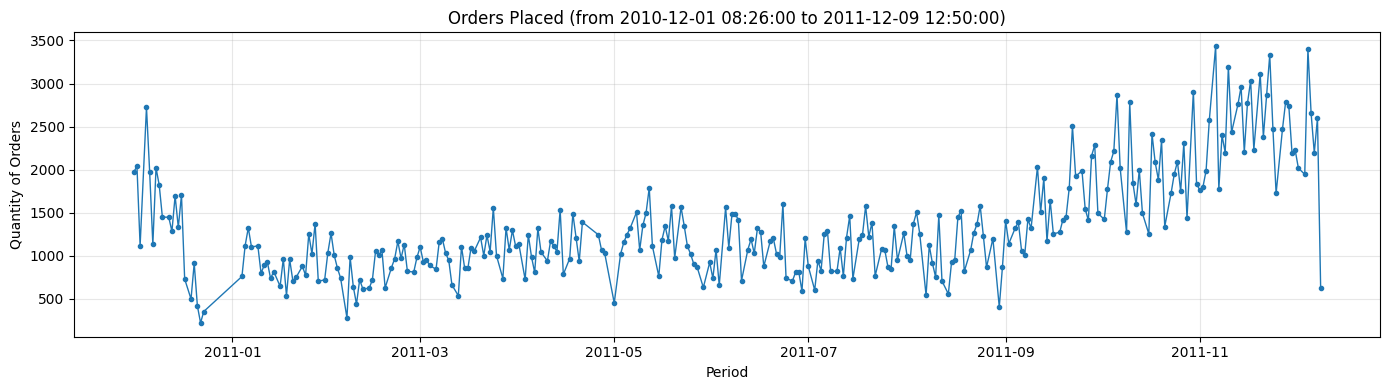

In [ ]:
# Plot orders  over time
plt.figure(figsize=(14, 4))
plt.plot(orders_per_day['InvoiceDate'], orders_per_day['Quantity'], marker='o', markersize=3, linewidth=1)
plt.title('Orders Placed (from 2010-12-01 08:26:00 to 2011-12-09 12:50:00)')
plt.xlabel('Period')
plt.ylabel('Quantity of Orders')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Insights:
- Our data does not seem to fit a poisson distribution

** We use the Poisson distribution when: **
- Events occur independently
- One event happening does not influence the next.
- Events occur at a constant average rate λ (lambda).
- Example: 20 customers per hour on average.
- You are counting events within a fixed time/space interval.
- Example: calls per minute, returns per day.
- Events are relatively rare compared to the possible opportunities for them to occur.

# For academic/ learning purposes
#### **Calcluate the probabilities**

Ojective: probability of attaining at least 100 orders per day.  With this at mind three core approached come about:

- **Probability Mass Functoin(PMF)**: **exactly** k=100 
- **Cumulative Density Function(CDF)**: **atmost** k values/ events k <= 100
- **1 - Cumulative Density Function(CDF)**: **atleast** k events k >= 100  **

In [ ]:
k  = 10 # 

# attaining exactly 10 orders (PMF) => k=10: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 10 orders (CDF) => k<=10:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 10 orders (CDF) => k >= 10:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 10 outcomes is 0.000000 
Probabilty of getting atmost 10 outcomes is 0.000000 
Probabilty of getting atleast 10 outcomes is 1.000000 


In [ ]:
k  = 5 # 

# attaining exactly 5 orders (PMF) => k=5: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 5 orders (CDF) => k<=5:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 5 orders (CDF) => k >= 5:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 5 outcomes is 0.000000 
Probabilty of getting atmost 5 outcomes is 0.000000 
Probabilty of getting atleast 5 outcomes is 1.000000 


In [ ]:
k  = 2 # 

# attaining exactly 2 orders (PMF) => k=2: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 2 orders (CDF) => k<=5:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 2 orders (CDF) => k >= 2:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 2 outcomes is 0.000000 
Probabilty of getting atmost 2 outcomes is 0.000000 
Probabilty of getting atleast 2 outcomes is 1.000000 


In [ ]:
k  = 1 # 

# attaining exactly 1 orders (PMF) => k=1: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 1 orders (CDF) => k<=1:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 1 orders (CDF) => k >= 1:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 1 outcomes is 0.000000 
Probabilty of getting atmost 1 outcomes is 0.000000 
Probabilty of getting atleast 1 outcomes is 1.000000 


## ** Visualizing the distribution: **

In [ ]:
# function to plot a histogram: 

def plotHist(data):
   
    lambda_hat = data.mean()

    # Plot histogram with whole 100 records
    counts, bins, patches = plt.hist(data , bins=5, alpha=0.7, 
                                    color='skyblue', edgecolor='black', 
                                    density=True, label='Actual data')
    # Generate points for the Poisson distribution line
    x = np.arange(data.min() - 2, data.max() + 3, 1) #To Create a SMOOTH LINE for the Theoretical Distribution
    poisson_values = stats.poisson.pmf(x, lambda_hat)

    # Plot Poisson distribution line
    plt.plot(x, poisson_values, 'ro-', linewidth=2, markersize=8, 
            label=f'Poisson distribution (λ={lambda_hat:.2f})', 
            markerfacecolor='red', markeredgecolor='darkred')

    # Add vertical line for the mean
    plt.axvline(lambda_hat, color='green', linestyle='--', 
                linewidth=2, label=f'Mean = {lambda_hat:.2f}')

    # Customize the plot
    plt.xlabel('Number of Orders per Day', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.title('Distribution of Daily Order Volume', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # Add value labels on the histogram bars
    for i, (bins, patches) in enumerate(zip(bins[:-1], patches)):
        height = patches.get_height()
        if height > 0:
            plt.text(bins + 0.5, height + 0.01, 
                    f'{data.iloc[i]}', 
                    ha='center', fontsize=10)

    # Add text box with statistics
    stats_text = f'Total days: {len(data)}\nMean (λ): {lambda_hat:.2f}\nVariance: {data.var():.2f}'
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

In [ ]:
df_1 = calls_per_day['Quantity'].loc[:1] 
df_5 = calls_per_day['Quantity'].loc[:5] 
df_10 = calls_per_day['Quantity'].loc[:10] 
df_20 = calls_per_day['Quantity'].loc[:20] 
df_50 = calls_per_day['Quantity'].loc[:50] 
df_all = calls_per_day['Quantity']

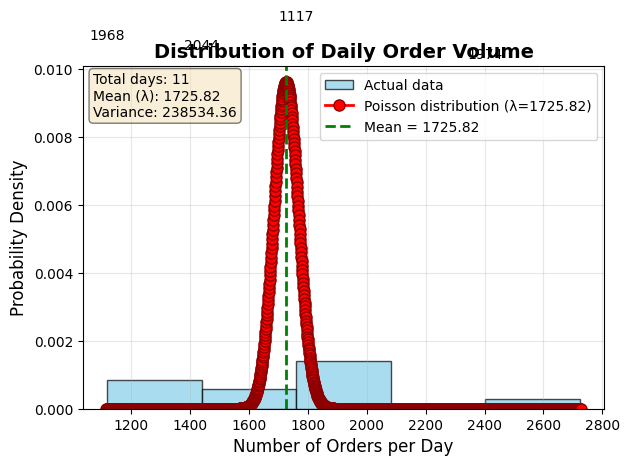

In [ ]:
plotHist(df_10)

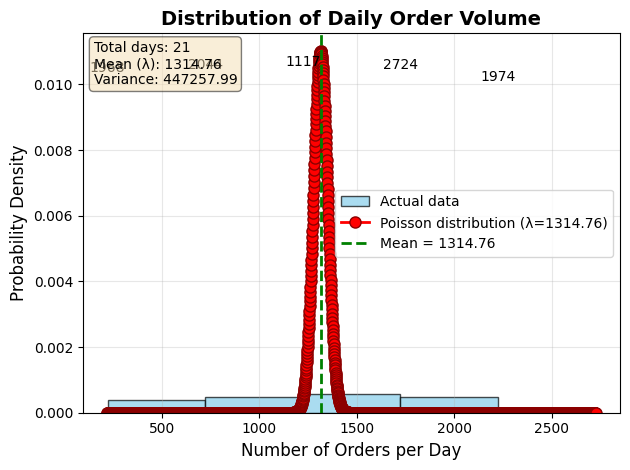

In [ ]:
plotHist(df_20)

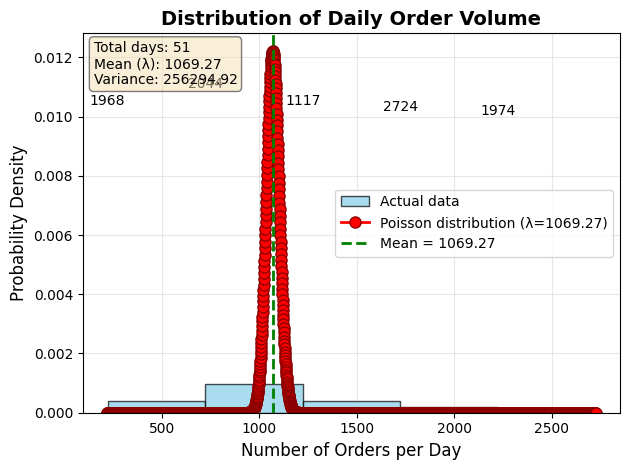

In [ ]:
plotHist(df_50)

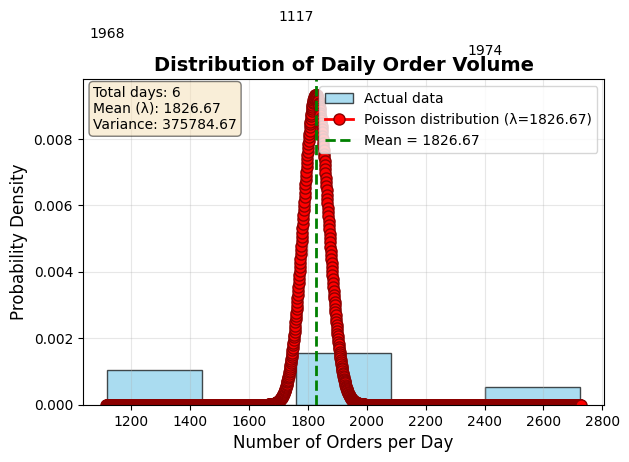

In [ ]:
plotHist(df_5)

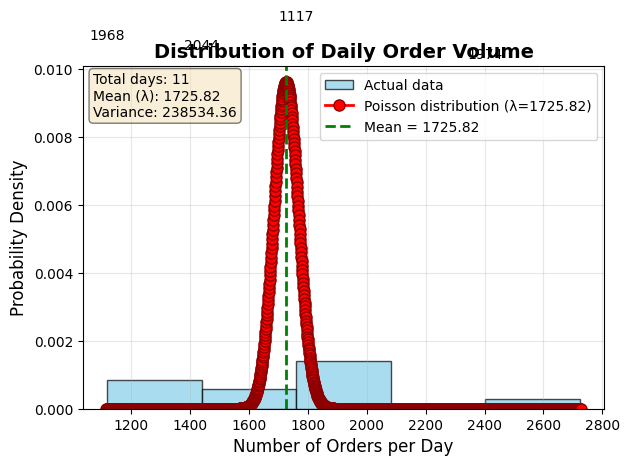

In [ ]:
plotHist(df_10)

Text(0.5, 1.0, 'Q-Q Plot against Poisson')

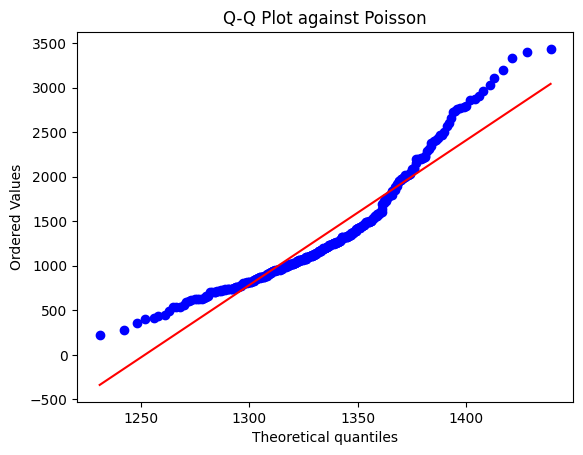

In [ ]:
stats.probplot(orders_per_day['Quantity'], dist="poisson", sparams=(lambda_hat,), plot=plt)
plt.title('Q-Q Plot against Poisson')

## ** Insights **
 - The dataset does not fit poisson distribution hence the visualizations
 - Good lesson learnt is to understand the kind of data ( discrete or continous) and apply the distribution that fits the data  including visualizations
